# 03 · Modeling & Evaluation

Building on the EDA, this notebook trains the full model zoo, compares them with cross-validation, tunes the strongest tree model, inspects calibration, and reads feature importances. Every step uses the same reproducible feature matrix.

In [1]:
# Make the package importable from a fresh checkout (no install needed).
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'employee_churn').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from employee_churn.data import make_synthetic_employee_data
from employee_churn.features.engineer_structured import (
    add_career_progression_features, add_tenure_bands,
    add_promotion_velocity, add_compensation_features, add_team_metrics,
)
from employee_churn.features.engineer_text import add_text_statistics
from employee_churn.nlp.sentiment import add_sentiment_scores
from employee_churn.nlp.emotion import add_emotion_features

df = make_synthetic_employee_data(n=1500, seed=42)
f = add_career_progression_features(df, 'hire_date', 'last_promotion_date')
f = add_tenure_bands(f)
f = add_promotion_velocity(f, 'num_promotions')
f = add_compensation_features(f, 'monthly_salary', 'department')
f = add_team_metrics(f, 'team_id')
f = add_sentiment_scores(f, 'feedback')
f = add_emotion_features(f, 'feedback')
f = add_text_statistics(f, 'feedback')

DROP = ['employee_id', 'churned', 'feedback', 'gender', 'department',
        'hire_date', 'last_promotion_date', 'team_id', 'tenure_band',
        'emotion_dominant']
X = f.drop(columns=DROP).select_dtypes(include=['number', 'bool'])
y = f['churned']
print('feature matrix:', X.shape)

feature matrix: (1500, 31)


## Feature matrix

The engineered matrix has **31 numeric/boolean features** per employee: structured signals (tenure, promotion velocity, peer-relative compensation, team size) plus the text-derived sentiment, emotion, and text-statistics columns. Identifiers, raw dates, and the categorical `tenure_band`/`emotion_dominant` labels are dropped.

,roc_auc_mean,roc_auc_std,f1_mean,f1_std
log_reg,0.705,0.037,0.557,0.036
random_forest,0.701,0.032,0.587,0.044
gradient_boosting,0.690,0.033,0.570,0.029
hist_gradient_boosting,0.658,0.025,0.560,0.041


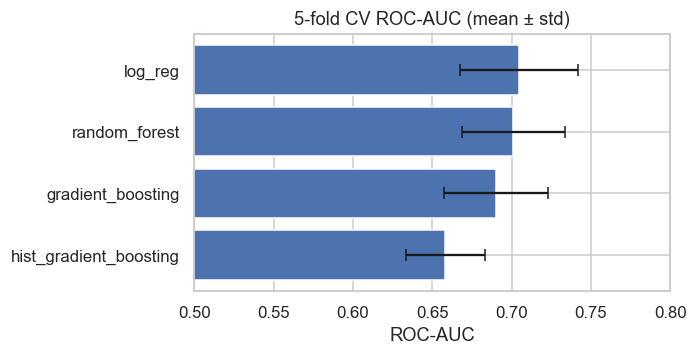

In [3]:
from employee_churn.models.train import build_model_zoo, cross_validate_models
zoo = build_model_zoo(random_state=0)
cv = cross_validate_models(zoo, X, y, cv=5)
cv_df = pd.DataFrame(cv).T.sort_values('roc_auc_mean', ascending=False)
display(cv_df.round(3))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.barh(cv_df.index, cv_df['roc_auc_mean'], xerr=cv_df['roc_auc_std'],
        color='#4c72b0', capsize=4)
ax.set_xlim(0.5, 0.8); ax.invert_yaxis()
ax.set_title('5-fold CV ROC-AUC (mean ± std)'); ax.set_xlabel('ROC-AUC')
plt.tight_layout(); plt.show()

## Model comparison

All four models land in a **narrow 0.66–0.71 ROC-AUC band**, with **logistic regression marginally ahead (~0.70)** of random forest and gradient boosting. The error bars overlap, so no model is decisively best — and the simplest, most interpretable one is competitive. The modest ceiling is expected: the synthetic target deliberately carries substantial noise, so this is a realistic 'no free lunch' result rather than a leaderboard-topping score. We carry the random forest forward because it gives us SHAP-friendly feature importances for notebook 04.

In [4]:
from sklearn.model_selection import train_test_split
from employee_churn.models.train import tune_hyperparameters
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)
# Tune the random forest and carry this single model through the rest of
# the notebook (and the fairness notebook) for a consistent story.
best, params, cv_auc = tune_hyperparameters(
    zoo['random_forest'], X_tr, y_tr, model_name='random_forest', n_iter=5)
best.fit(X_tr, y_tr)
print('tuned params:', params, '| CV AUC:', round(cv_auc, 3))

tuned params: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_depth': 4} | CV AUC: 0.697


## Tuning the carried-forward model

Randomized search nudges the random forest toward a shallower, more regularized configuration (`max_depth=4`, `min_samples_leaf=4`, `n_estimators=200`, CV AUC ≈ 0.70), which guards against overfitting on 1,125 training rows. Everything below evaluates this tuned model.

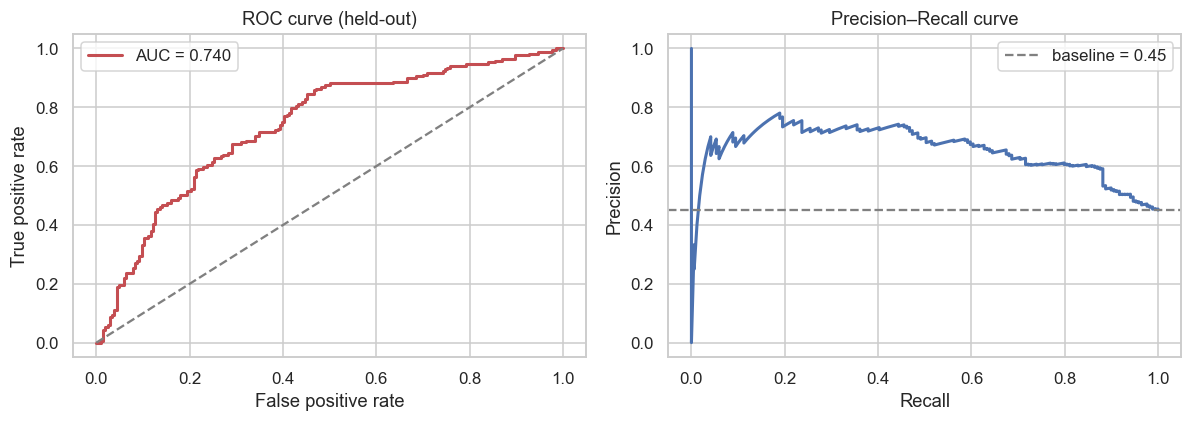

In [5]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             ConfusionMatrixDisplay)
proba = best.predict_proba(X_te)[:, 1]

fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, color='#c44e52', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[0].plot([0, 1], [0, 1], ls='--', c='gray')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve (held-out)'); axes[0].legend()
axes[1].plot(rec, prec, color='#4c72b0', lw=2)
axes[1].axhline(y_te.mean(), ls='--', c='gray', label=f'baseline = {y_te.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall curve'); axes[1].legend()
plt.tight_layout(); plt.show()

## Held-out discrimination

On the 25% hold-out the random forest reaches **ROC-AUC ≈ 0.74** — a bit above its cross-validated mean, within normal split-to-split variance. The precision–recall curve sits comfortably above the 0.45 base rate, confirming the model ranks at-risk employees better than chance across the whole threshold range.

discrimination: {'roc_auc': 0.74, 'f1': 0.559, 'precision_at_k': 0.7}
calibration   : {'brier_score': 0.207, 'expected_calibration_error': 0.063, 'max_calibration_error': 0.412}


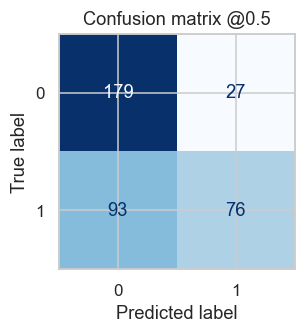

In [6]:
from employee_churn.models.evaluate import evaluate_model
report = evaluate_model(best, X_te, y_te, top_k=20)
print('discrimination:', {k: round(v, 3) for k, v in report['discrimination'].items()})
print('calibration   :', {k: round(v, 3) for k, v in report['calibration'].items()})

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ConfusionMatrixDisplay.from_predictions(
    y_te, (proba >= 0.5).astype(int), ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix @0.5'); plt.tight_layout(); plt.show()

## Precision@k for targeted outreach

HR can only act on a limited number of people per cycle, so **precision@k** is the operationally honest metric. Among the model's 20 highest-risk employees, **~70% truly churned** — a strong shortlist for retention conversations even though the global AUC is modest.

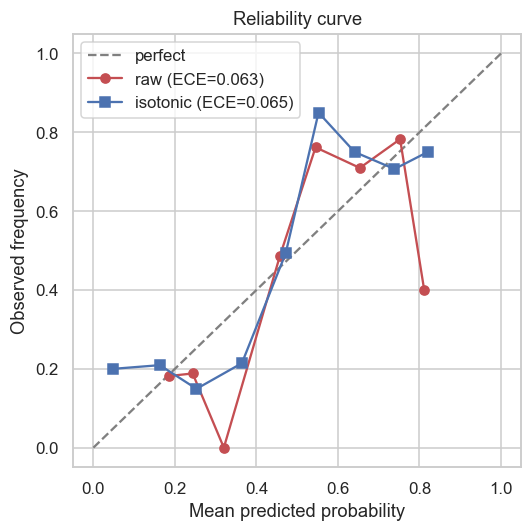

In [7]:
from employee_churn.models.calibrate import calibration_improvement, reliability_curve
calib = calibration_improvement(best, X_tr, y_tr, X_te, y_te)
base_curve = reliability_curve(y_te, best.predict_proba(X_te)[:, 1])
cal_model = calib['calibrated_model']
cal_curve = reliability_curve(y_te, cal_model.predict_proba(X_te)[:, 1])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls='--', c='gray', label='perfect')
ax.plot(base_curve['mean_predicted'], base_curve['fraction_positive'],
        'o-', color='#c44e52', label=f"raw (ECE={calib['baseline']['expected_calibration_error']:.3f})")
ax.plot(cal_curve['mean_predicted'], cal_curve['fraction_positive'],
        's-', color='#4c72b0', label=f"isotonic (ECE={calib['calibrated']['expected_calibration_error']:.3f})")
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title('Reliability curve'); ax.legend()
plt.tight_layout(); plt.show()

## Calibration — an honest result

**Isotonic calibration does *not* improve ECE here** (it edges from ~0.063 to ~0.065). On a dataset this size the isotonic fit adds variance that outweighs the small bias it removes — a real reminder that calibration is an empirical question, not a guaranteed win. In production you would prefer Platt/sigmoid scaling on small samples, or simply keep the raw probabilities and monitor ECE over time.

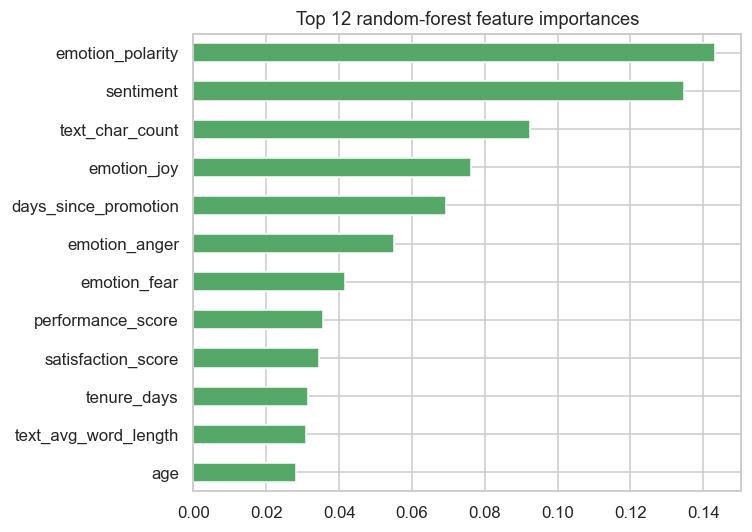

emotion_polarity       0.143
sentiment              0.135
text_char_count        0.093
emotion_joy            0.076
days_since_promotion   0.069
emotion_anger          0.055
emotion_fear           0.042
performance_score      0.036
dtype: float64

In [8]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.tail(12).plot.barh(ax=ax, color='#55a868')
ax.set_title('Top 12 random-forest feature importances')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).head(8).round(3)

## What the model actually uses

The importance ranking validates the EDA decisively: the **top two features are `emotion_polarity` and `sentiment`** (~0.14 each), with `text_char_count` and individual emotions (`emotion_joy`, `emotion_anger`, `emotion_fear`) close behind. `days_since_promotion` is the only structured feature near the top. **Roughly half of the model's predictive weight comes from the free-text feedback** — a strong argument for investing in richer NLP (the transformer sentiment backend on the roadmap) rather than collecting more structured HR fields.

## Takeaways

1. Models cluster around **0.70 CV AUC / 0.74 hold-out**; logistic regression is competitive with the trees.
2. **Precision@20 ≈ 0.70** makes the model useful for targeted outreach despite the modest global AUC.
3. **Calibration did not help** on this sample size — verify, don't assume.
4. **Text features dominate importances**, confirming the EDA thesis.